## import dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
import cv2
from PIL import Image


In [3]:
# !pip install imagecodecs

## load the images deom disk

In [4]:
# tifffile.imread("Input/EMF/AF B/tiff/B1.tif")

In [5]:
import os
import numpy as np
import tensorflow as tf
from PIL import Image
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Paths to TIFF image folders
af_dir_450 = "C:/Users/Admin/Desktop/Example images/New data/Combined/B_tiff"
af_dir_510 = "C:/Users/Admin/Desktop/Example images/New data/Combined/G_tiff"
af_dir_590 = "C:/Users/Admin/Desktop/Example images/New data/Combined/R_tiff"
af_dir_LP  = "C:/Users/Admin/Desktop/Example images/New data/Combined/LP_tiff"
he_dir     = "C:/Users/Admin/Desktop/Example images/New data/Combined/HE_tiff"




# Function to load all TIFF images from a directory
def load_tiff_images(directory):
    images = []
    filenames = sorted(os.listdir(directory))
    for filename in filenames:
        if filename.lower().endswith(('.tif', '.tiff')):
            img_path = os.path.join(directory, filename)
            img = Image.open(img_path)
            images.append(np.array(img))
    return images

# Load all images from each directory
af450_images = load_tiff_images(af_dir_450)
af510_images = load_tiff_images(af_dir_510)
af590_images = load_tiff_images(af_dir_590)
afLP_images  = load_tiff_images(af_dir_LP)
he_images    = load_tiff_images(he_dir)


# Verify number of loaded images
print(f"AF450 Images: {len(af450_images)}")
print(f"AF510 Images: {len(af510_images)}")
print(f"AF590 Images: {len(af590_images)}")
print(f"AF LP Images: {len(afLP_images)}")
print(f"HE Images: {len(he_images)}")


AF450 Images: 14
AF510 Images: 14
AF590 Images: 14
AF LP Images: 14
HE Images: 14


## crop corresponding images from each channel to make them of same size

Example patch shape (AF 450): (1990, 1910, 4)
Example patch shape (AF 450): (1990, 1909, 4)
Example patch shape (AF 450): (1990, 1909, 4)
Example patch shape (AF 450): (1990, 1901, 4)
Example patch shape (AF 450): (1990, 1909, 4)


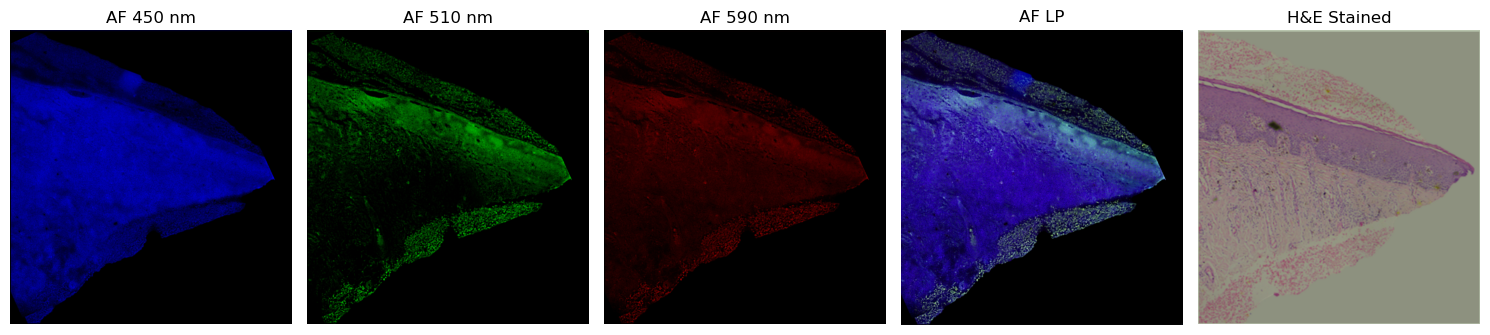

In [6]:
img_index= 5
print(f"Example patch shape (AF 450): {af450_images[img_index].shape}")
print(f"Example patch shape (AF 450): {af510_images[img_index].shape}")
print(f"Example patch shape (AF 450): {af590_images[img_index].shape}")
print(f"Example patch shape (AF 450): {afLP_images[img_index].shape}")
print(f"Example patch shape (AF 450): {he_images[img_index].shape}")

# Visualize the first image (index 0) from each set


plt.figure(figsize=(15, 5))

plt.subplot(1, 5, 1)
plt.imshow(af450_images[img_index], cmap='gray')
plt.title("AF 450 nm")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(af510_images[img_index], cmap='gray')
plt.title("AF 510 nm")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(af590_images[img_index], cmap='gray')
plt.title("AF 590 nm")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(afLP_images[img_index], cmap='gray')
plt.title("AF LP")
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(he_images[img_index])  # H&E is usually RGB
plt.title("H&E Stained")
plt.axis('off')

plt.tight_layout()
plt.show()


In [7]:
def center_crop(image, target_size):
    h, w = image.shape[:2]
    th, tw = target_size

    top = max((h - th) // 2, 0)
    left = max((w - tw) // 2, 0)
    return image[top:top+th, left:left+tw]

def resize_stacks_to_match(stack1, stack2, stack3, stack4, stack5):
    num_images = len(stack1)

    out1, out2, out3, out4, out5 = [], [], [], [], []

    for i in range(num_images):
        imgs = [stack1[i], stack2[i], stack3[i], stack4[i], stack5[i]]
        heights = [img.shape[0] for img in imgs]
        widths = [img.shape[1] for img in imgs]

        target_h = min(heights)
        target_w = min(widths)
        target_size = (target_h, target_w)

        cropped_imgs = [center_crop(img, target_size) for img in imgs]

        out1.append(cropped_imgs[0])
        out2.append(cropped_imgs[1])
        out3.append(cropped_imgs[2])
        out4.append(cropped_imgs[3])
        out5.append(cropped_imgs[4])

    return out1, out2, out3, out4, out5

In [8]:
af450_images_cropped, af510_images_cropped, af590_images_cropped, afLP_images_cropped, he_images_cropped =  resize_stacks_to_match(af450_images, af510_images, af590_images, afLP_images, he_images)

## combine the Blue Green and Red channel images to create a 3 channel composite image

## for now I am ignoring the LP images

In [9]:
def prepare_af_input_stack(af450_stack, af510_stack, af590_stack):
    composite_stack = []
    for img450, img510, img590 in zip(af450_stack, af510_stack, af590_stack):
        ch1 = cv2.cvtColor(img450, cv2.COLOR_BGR2GRAY)
        ch2 = cv2.cvtColor(img510, cv2.COLOR_BGR2GRAY)
        ch3 = cv2.cvtColor(img590, cv2.COLOR_BGR2GRAY)

        stacked = np.stack([ch1, ch2, ch3], axis=-1)
        composite_stack.append(stacked.astype(np.uint8))

    return composite_stack

In [10]:
af_input_stack = prepare_af_input_stack(af450_images_cropped, af510_images_cropped, af590_images_cropped)

Text(0.5, 1.0, 'HE Image')

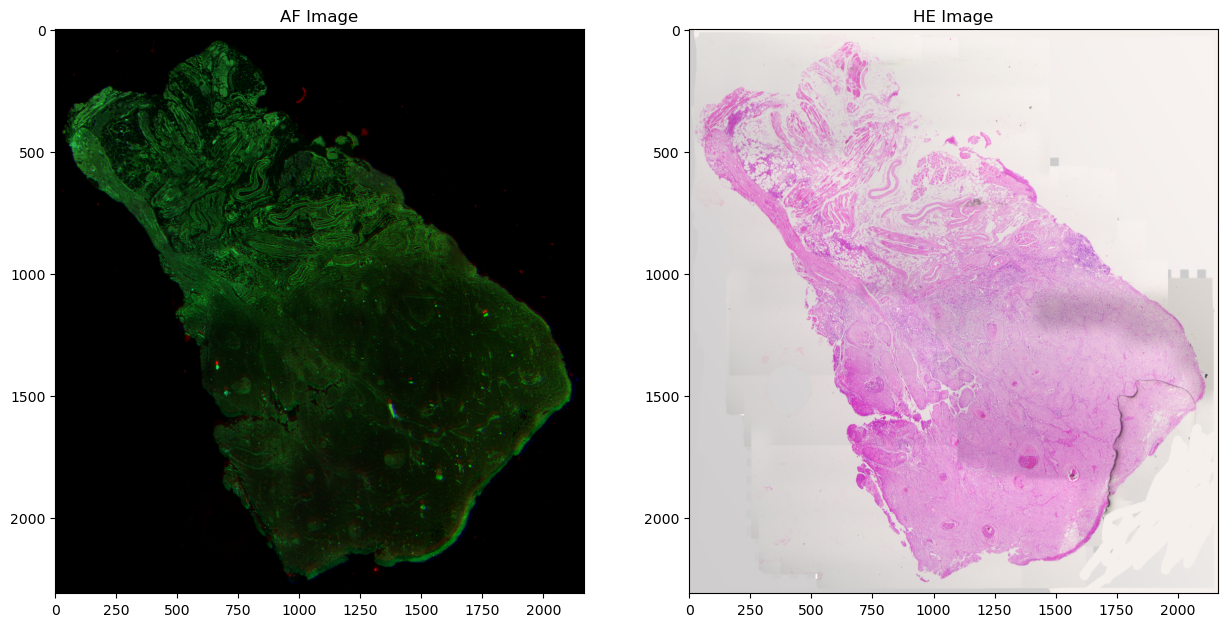

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(af_input_stack[8], cmap = 'gray')
ax[0].set_title('AF Image')
ax[1].imshow(he_images_cropped[8], cmap = 'gray')
ax[1].set_title('HE Image')

## we will now extract random patches from each corresponding images fro training

In [12]:
def extract_random_patches(input_stack, target_stack, patch_size=(32, 32), num_patches=5500):
    patch_h, patch_w = patch_size
    X = []
    Y = []
    for _ in range(num_patches):

        # Randomly select an image index
        idx = np.random.randint(0, len(input_stack) - 1)
        inp_img = input_stack[idx]
        tgt_img = target_stack[idx]
        h, w, _ = inp_img.shape

        # Ensure patch fits in image
        if h < patch_h or w < patch_w:
            continue
        # Randomly select top-left corner
        top = np.random.randint(0, h - patch_h)
        left = np.random.randint(0, w - patch_w)

        inp_patch = inp_img[top:top+patch_h, left:left+patch_w, :]
        tgt_patch = tgt_img[top:top+patch_h, left:left+patch_w, :]

        X.append(inp_patch)
        Y.append(tgt_patch)

    X = np.array(X)
    Y = np.array(Y)
    return X, Y


## normalize the patches for training

In [13]:
# X_patches, Y_patches = extract_random_patches( af_input_stack, he_images_cropped, patch_size=(128, 128), num_patches=5500)
X_patches, Y_patches = extract_random_patches( afLP_images_cropped, he_images_cropped, patch_size=(128, 128), num_patches=5500)
X_patches = X_patches.astype(np.float32) / 255.0
Y_patches = Y_patches.astype(np.float32) / 255.0
Y_patches = Y_patches[:,:,:,:3]

## check if the patches align

Text(0.5, 1.0, 'HE Image')

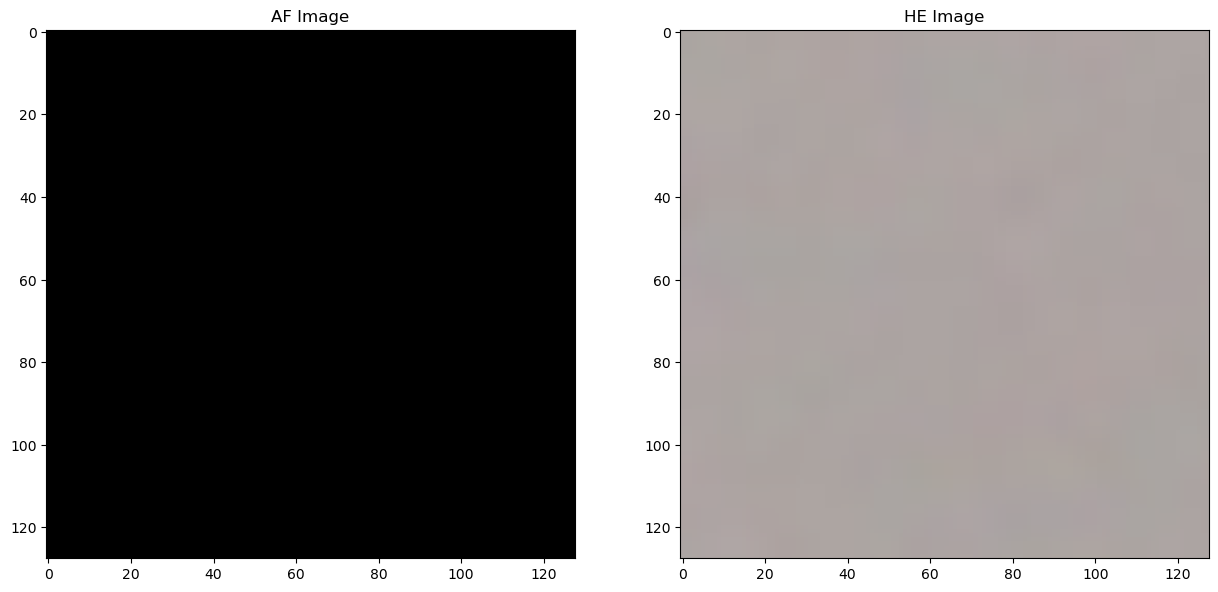

In [14]:
num = 3000

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_patches[num], cmap = 'gray')
ax[0].set_title('AF Image')
ax[1].imshow(Y_patches[num], cmap = 'gray')
ax[1].set_title('HE Image')

## import tensorflow

In [15]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
from tensorflow.image import ssim

from tensorflow.keras.utils import plot_model

In [16]:
def build_unet(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)
    p3 = layers.MaxPooling2D()(c3)

    # Bottleneck
    bn = layers.Conv2D(256, 3, activation='relu', padding='same')(p3)

    # Decoder
    u1 = layers.UpSampling2D()(bn)
    concat1 = layers.Concatenate()([u1, c3])
    d1 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat1)

    u2 = layers.UpSampling2D()(d1)
    concat2 = layers.Concatenate()([u2, c2])
    d2 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat2)

    u3 = layers.UpSampling2D()(d2)
    concat3 = layers.Concatenate()([u3, c1])
    d3 = layers.Conv2D(32, 3, activation='relu', padding='same')(concat3)

    # Output: 3-channel RGB image
    outputs = layers.Conv2D(3, 1, activation='sigmoid')(d3) # i am using sigmoid function for now (to enhance contrast in the predicted image). You may use linear/relu for more faithful prediction

    return Model(inputs, outputs)

In [17]:
model = build_unet(input_shape=(128, 128, 3))


In [18]:
plot_model(model, show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## combined mse and structural similarity index loss

In [19]:
def combined_loss(y_true, y_pred):
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim_loss = 1 - tf.reduce_mean(ssim(y_true, y_pred, max_val=1.0))
    combined_loss = mse_loss + 0.6*ssim_loss    ## change the prefactors and look at the training graphs
    return combined_loss

In [20]:
model.compile(optimizer='adam', loss=combined_loss, metrics=['mae'])

In [21]:
X_patches = X_patches[:, :, :, :3]

print(f"Example patch shape (AF 450): {X_patches.shape}")
print(f"Example patch shape (AF 450): {Y_patches.shape}")


Example patch shape (AF 450): (5500, 128, 128, 3)
Example patch shape (AF 450): (5500, 128, 128, 3)


## train the model

In [69]:
history = model.fit(X_patches, Y_patches, batch_size=32, epochs=100, validation_split=0.1)

Epoch 1/100


KeyboardInterrupt: 

In [22]:
# os.mkdir('trained_model')

# model.save('trained_model/model_2.keras')

## save the trained weights

In [23]:
model.save_weights('C:/Users/Admin/Python codes/Final codes/Saved models/New_Fianl_LP_100 itterartion_weights_3_A.weights...............h5')

Text(0.5, 1.0, 'Training and Validation MAE')

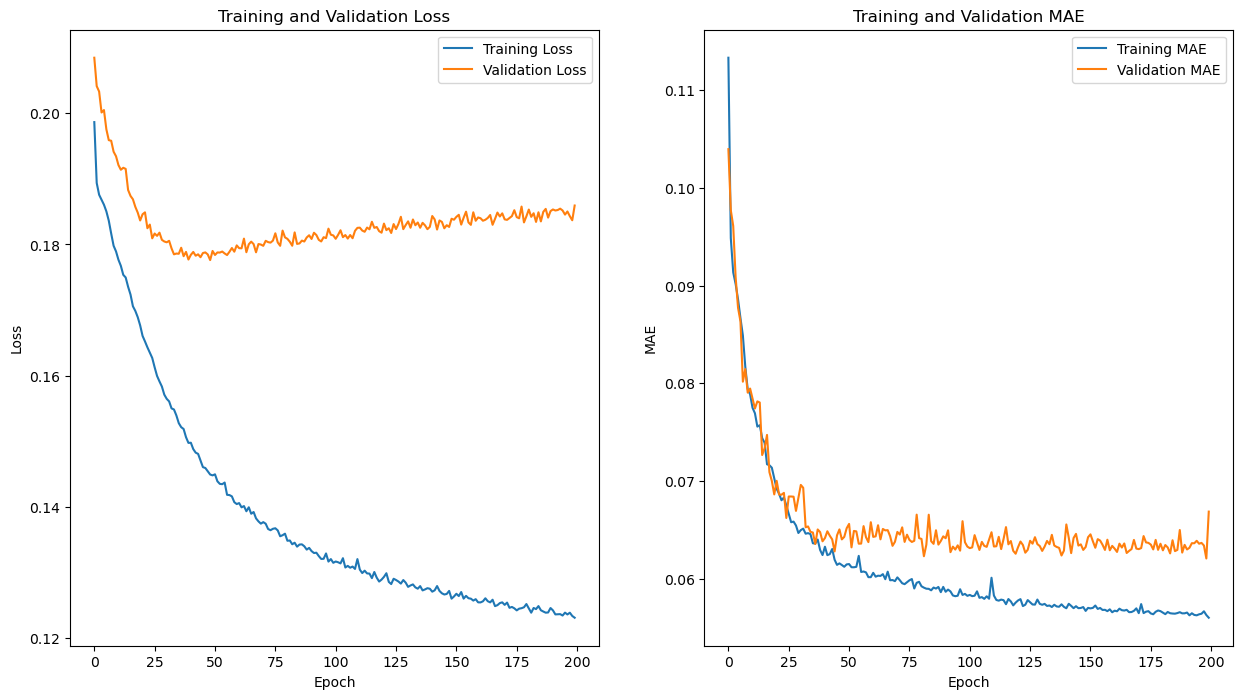

In [157]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].plot(history.history['loss'], label='Training Loss')
ax[0].plot(history.history['val_loss'], label='Validation Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].set_title('Training and Validation Loss')
ax[1].plot(history.history['mae'], label='Training MAE')
ax[1].plot(history.history['val_mae'], label='Validation MAE')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('MAE')
ax[1].legend()
  Him

In [158]:
import pandas as pd

df = pd.DataFrame(history.history)
df.to_csv('C:/Users/Admin/Python codes/Final codes/Saved models/history_D_new_new_1.csv', index=False)

## look at the predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step


Text(0.5, 1.0, 'Predicted HE Image')

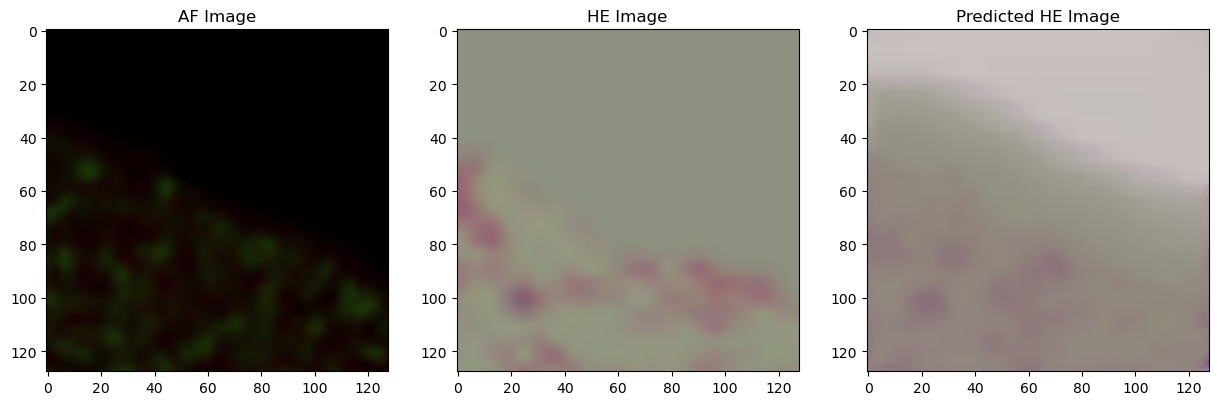

In [159]:
num = 390
x_test = X_patches[num]
y_test = Y_patches[num]

y_pred = model.predict(np.expand_dims(x_test, axis=0))[0]

fig, ax = plt.subplots(1, 3, figsize=(15, 8))
ax[0].imshow(x_test, cmap = 'gray')
ax[0].set_title('AF Image')
ax[1].imshow(y_test, cmap = 'gray')
ax[1].set_title('HE Image')
ax[2].imshow(y_pred, cmap = 'gray')
ax[2].set_title('Predicted HE Image')

## Loading the model and testing on whole image

Example patch shape (AF 450): (1280, 1280, 3)


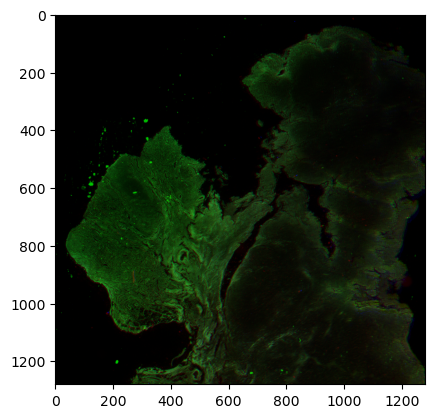

In [22]:
index =1
# XX = afLP_images_cropped[index] [0:256+1024, 0:256+1024,:].astype(np.float32) / 255.0
XX = af_input_stack[index][0:256+1024, 0:256+1024,:].astype(np.float32) / 255.0

XX = XX[:, :, :3]

print(f"Example patch shape (AF 450): {XX.shape}")

plt.imshow(XX)

In [23]:
model2 = build_unet(input_shape=XX.shape)
model2.load_weights(r'C:/Users/Admin/Python codes/Final codes/Saved models/Final models/New_Fianl_MS_100 itterartion_weights_3_A.weights.h5')

In [24]:
YY = model2.predict(np.expand_dims(XX, axis=0))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


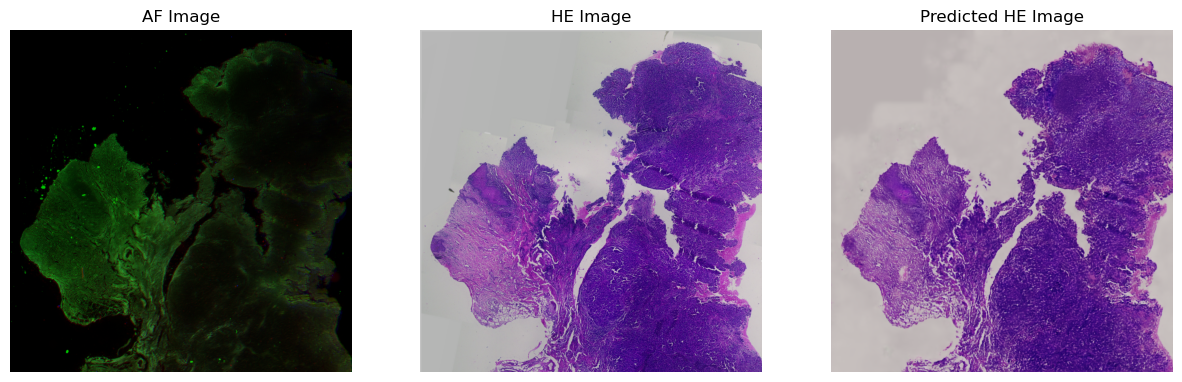

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(15, 8))
ax[0].imshow(XX, cmap = 'gray')
ax[0].set_title('AF Image')
ax[1].imshow(he_images_cropped[index][0:256+1024, 0:256+1024,:], cmap = 'gray')
ax[1].set_title('HE Image')
ax[2].imshow(YY, cmap = 'gray')
ax[2].set_title('Predicted HE Image')
# Remove axes from all subplots
for a in ax:
    a.set_axis_off()



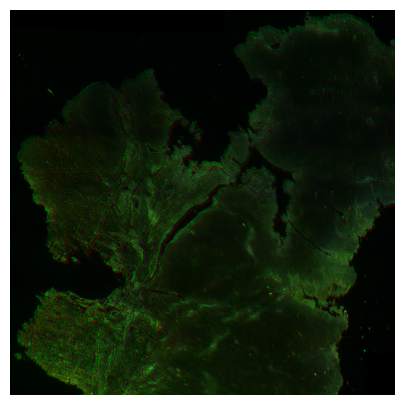

In [148]:
XX = af_input_stack[index][0:256+1024, 0:256+1024,:].astype(np.float32) / 255.0
plt.figure(figsize=(5, 5))
plt.imshow(XX, cmap='gray')
plt.axis('off')
# plt.savefig('C:/Users/Admin/Python codes/Final codes/Saved models/thickness/2micron_MS.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [50]:
## For saving the image 

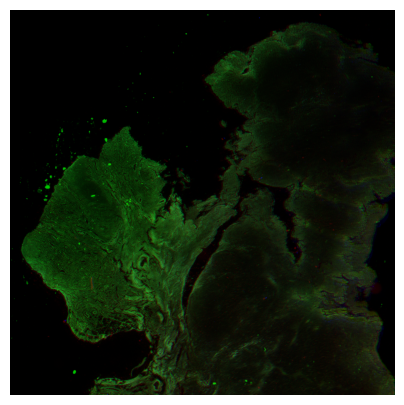

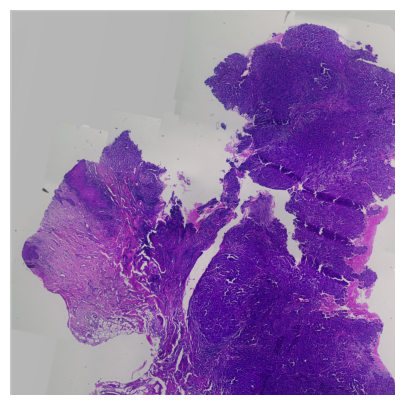

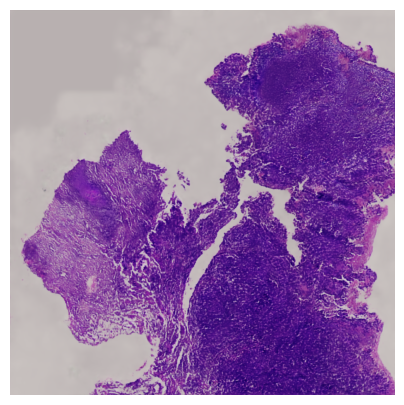

In [150]:
# Display and save AF Image
plt.figure(figsize=(5, 5))
plt.imshow(XX, cmap='gray')
plt.axis('off')
plt.savefig('C:/Users/Admin/Python codes/Final codes/Saved models/Thickness/AF_4.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

# Display and save HE Image
plt.figure(figsize=(5, 5))
plt.imshow(he_images_cropped[index][0:256+1024, 0:256+1024,:], cmap='gray')
plt.axis('off')
plt.savefig('C:/Users/Admin/Python codes/Final codes/Saved models/Thickness/VS_4.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

# Display and save Predicted HE Image
plt.figure(figsize=(5, 5))
plt.imshow(YY, cmap='gray')
plt.axis('off')
plt.savefig('C:/Users/Admin/Python codes/Final codes/Saved models/Thickness/HE_4.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()


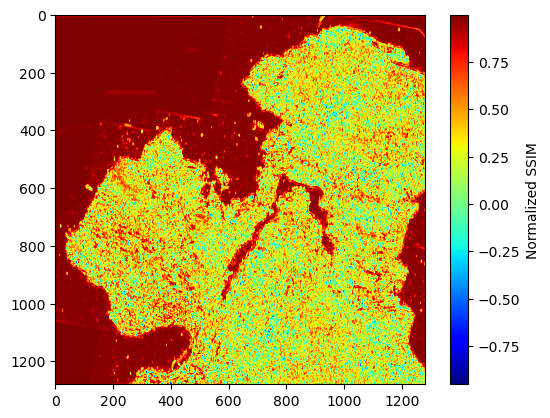

In [26]:
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr, mean_squared_error as mse

# # Example: Assuming both images are 2D numpy arrays (grayscale)
# img1 = he_images_cropped[3][0:256+1024, 0:256+1024,:]      # Ground truth
# img1 = img1[:, :, :3]
# img2 = YY       # Prediction


img1 = he_images_cropped[index][0:256+1024, 0:256+1024,:]
img1 = img1[:, :, :3]
img2 = YY
from skimage.color import rgb2gray

img1 = rgb2gray(img1)  # 2D array normalized [0,1]
img2 = rgb2gray(img2)  # 2D array normalized [0,1]


# Ensure both images are same shape and dtype
assert img1.shape == img2.shape
img1 = img1.astype(np.float64)
img2 = img2.astype(np.float64)

# SSIM

# Assuming img1 and img2 are the two images (same shape, dtype float64)

# ssim_value, ssim_map = ssim(img1, img2, full=True, data_range=img2.max() - img2.min(), channel_axis=-1)

# print("SSIM index:", ssim_value)

# # ssim_map is a 2D array of local SSIM values (if multichannel input, ssim_map is 2D)
# ssim_map_norm = (ssim_map - ssim_map.min()) / (ssim_map.max() - ssim_map.min())

# # Display SSIM map (whole FOV)
# plt.figure(figsize=(8, 8))

# plt.imshow(ssim_map_norm)
# plt.colorbar(label='SSIM local similarity')
# plt.title('SSIM Map - Local Structural Similarity')
# plt.axis('off')
# plt.show()
ssim_value, ssim_map = ssim(img1, img2, full=True, data_range=img2.max() - img2.min(), channel_axis=-1)

# ssim_map_norm = (ssim_map - ssim_map.min()) / (ssim_map.max() - ssim_map.min())


img_display = (ssim_map)
im = plt.imshow(img_display,cmap='jet')
plt.colorbar(im, label='Normalized SSIM')


# plt.figure(figsize=(8, 8))
# plt.imshow(ssim_map_norm, cmap='jet')
# plt.colorbar(label='SSIM local similarity')
# plt.title('SSIM Map - Local Structural Similarity')
# plt.axis('off')
# plt.show()


In [27]:
import numpy as np # Ensure this import is at the top of your script

# ... (Your existing code where ssim_map is calculated)
# ssim_value, ssim_map = ssim(img1, img2, full=True, data_range=img2.max() - img2.min(), channel_axis=-1)

# Define the filename
csv_filename = 'ssim_map_output_thickness.csv'

# Save the 2D ssim_map array to a CSV file
# 'fmt' formats the numbers, and 'delimiter' sets the separator to a comma
np.savetxt(csv_filename, ssim_map, fmt='%.6f', delimiter=',')

print(f"SSIM Map (shape: {ssim_map.shape}) successfully exported to {csv_filename}")

SSIM Map (shape: (1280, 1280)) successfully exported to ssim_map_output_thickness.csv


SSIM index: 0.6829105355667441


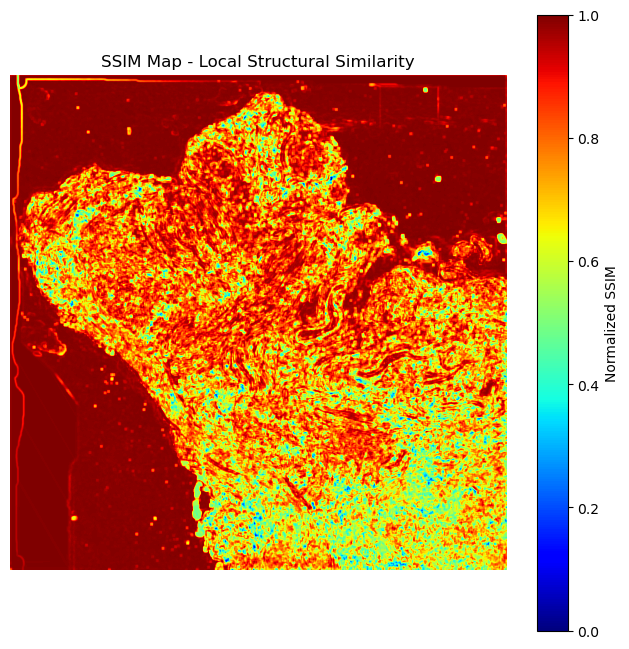

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.color import rgb2gray

# Convert input images to grayscale and normalize to [0, 1]
img1 = he_images_cropped[3][0:256+1024, 0:256+1024, :3]
img2 = YY[:, :, :3]  # Ensure same number of channels as img1

img1 = rgb2gray(img1)
img2 = rgb2gray(img2)

# Normalize images to range [0, 1]
img1 = img1.astype(np.float64)
img2 = img2.astype(np.float64)

img1 = (img1 - img1.min()) / (img1.max() - img1.min())
img2 = (img2 - img2.min()) / (img2.max() - img2.min())

# Ensure same shape
assert img1.shape == img2.shape, "Input images must have the same shape"

# Compute SSIM
ssim_value, ssim_map = ssim(img1, img2, full=True, data_range=1.0)

print("SSIM index:", ssim_value)  # This will always be in [0, 1]

# Normalize SSIM map for display (optional, but visually helpful)
ssim_map_norm = (ssim_map - ssim_map.min()) / (ssim_map.max() - ssim_map.min())

# Plot SSIM map
plt.figure(figsize=(8, 8))
im = plt.imshow(ssim_map_norm, cmap='jet')
plt.colorbar(im, label='Normalized SSIM')
plt.title('SSIM Map - Local Structural Similarity')
plt.axis('off')
plt.savefig('C:/Users/Admin/Python codes/Final codes/Saved models/predicted_he_image_B_3.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()
